In [1]:
import tensorflow as tf
(x_train,y_train),(x_test,y_test)= tf.keras.datasets.mnist.load_data()

In [2]:
x_train.shape

(60000, 28, 28)

In [3]:
x_test.shape

(10000, 28, 28)

In [4]:
x_train = x_train.reshape(x_train.shape[0],28,28,1)
x_test = x_test.reshape(x_test.shape[0],28,28,1)
input_shape = (28,28,1)

In [5]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [6]:
x_train /= 255 # mandatory step to normalize the pixel of image from 0 -255 to 0-1 range
x_test /= 255

In [7]:
#model creation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D

model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

C:\Users\premchandar\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
#model compile
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics = ['accuracy'])

In [9]:
#fitting the model
history = model.fit(x=x_train,y=y_train, epochs=10)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9484 - loss: 0.1660
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9818 - loss: 0.0580
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9879 - loss: 0.0409
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9900 - loss: 0.0323
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9912 - loss: 0.0271
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9925 - loss: 0.0224
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9936 - loss: 0.0187
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9945 - loss: 0.0158
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9961 - loss: 0.0126
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9964 - loss: 0.0111


In [10]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9915 - loss: 0.0322


[0.03224897012114525, 0.9915000200271606]

In [11]:
#predicting the labels_digit
y_predict = model.predict(x_test)
y_predict

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([[1.80784072e-14, 1.41858456e-10, 3.72247407e-11, ...,
        1.00000000e+00, 1.15366175e-14, 8.65388317e-12],
       [3.53092420e-13, 1.24366316e-12, 1.00000000e+00, ...,
        1.09635922e-12, 3.71168270e-15, 2.89217911e-18],
       [8.11452239e-10, 9.99992490e-01, 3.35649482e-08, ...,
        5.92951267e-07, 4.84448170e-09, 2.99842373e-09],
       ...,
       [1.08514242e-22, 1.66307681e-18, 5.77787412e-23, ...,
        9.70679508e-17, 2.74795564e-14, 7.71891596e-16],
       [6.96072988e-16, 4.89108058e-16, 7.06299928e-20, ...,
        8.02090932e-20, 3.49488372e-09, 2.88422871e-15],
       [2.15859079e-14, 7.07970321e-18, 2.28566385e-11, ...,
        3.07519458e-21, 4.13776272e-14, 7.86835137e-20]],
      shape=(10000, 10), dtype=float32)

In [12]:
#predicting the labels_digit
y_predict = model.predict(x_test)
y_predict

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


array([[1.80784072e-14, 1.41858456e-10, 3.72247407e-11, ...,
        1.00000000e+00, 1.15366175e-14, 8.65388317e-12],
       [3.53092420e-13, 1.24366316e-12, 1.00000000e+00, ...,
        1.09635922e-12, 3.71168270e-15, 2.89217911e-18],
       [8.11452239e-10, 9.99992490e-01, 3.35649482e-08, ...,
        5.92951267e-07, 4.84448170e-09, 2.99842373e-09],
       ...,
       [1.08514242e-22, 1.66307681e-18, 5.77787412e-23, ...,
        9.70679508e-17, 2.74795564e-14, 7.71891596e-16],
       [6.96072988e-16, 4.89108058e-16, 7.06299928e-20, ...,
        8.02090932e-20, 3.49488372e-09, 2.88422871e-15],
       [2.15859079e-14, 7.07970321e-18, 2.28566385e-11, ...,
        3.07519458e-21, 4.13776272e-14, 7.86835137e-20]],
      shape=(10000, 10), dtype=float32)

In [14]:
#Here we get the index of maximum value in the encoded vector.
import numpy as np
y_predicts = np.argmax(y_predict,axis=1)

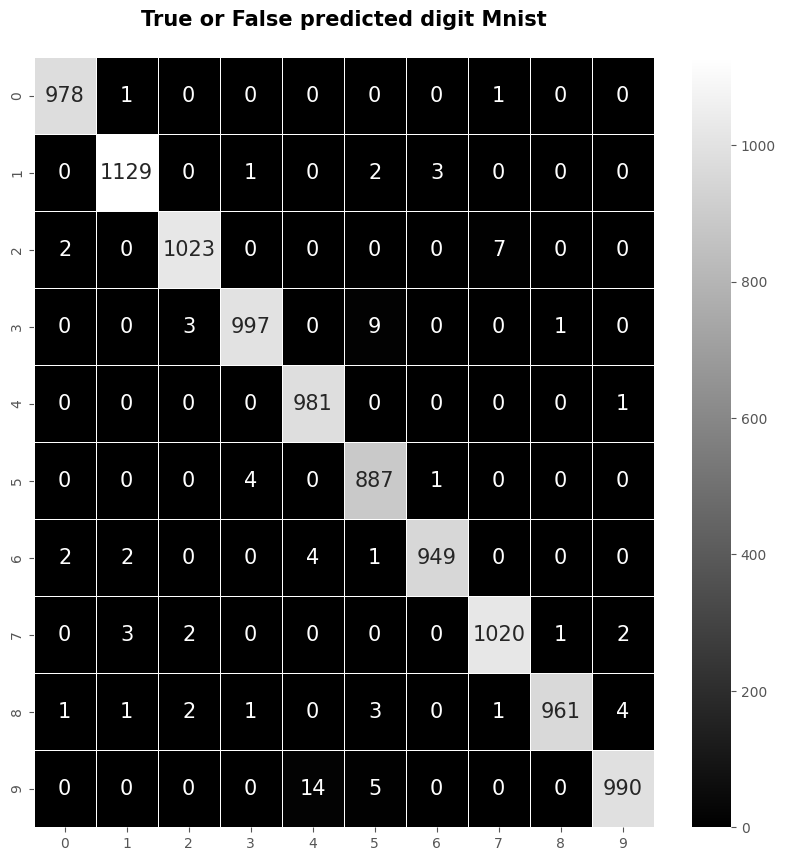

In [15]:
#Confusion matrix for digit mnist
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
con_mat = confusion_matrix(y_test,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit Mnist\n', fontweight='bold',fontsize=15)
plt.show()

In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predicts))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

